In [22]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error 

In [3]:
employee_df = pd.read_csv("employee_turnover.csv")

In [9]:
employee_df.columns
employee_df.info()
employee_df["Employee_Turnover"].nunique()
employee_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [10]:
X = employee_df.drop("Employee_Turnover", axis = 1)
y = employee_df["Employee_Turnover"]

In [11]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Employee_Turnover, dtype: int64

In [13]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
y_train[y_train == 1] #547
y_train[y_train == 0] #533

755     0
109     0
1040    0
774     0
983     0
       ..
330     0
1238    0
466     0
121     0
1044    0
Name: Employee_Turnover, Length: 533, dtype: int64

In [34]:
# Baseline Logistic Regression Model
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0])

In [21]:
print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))

accuracy: 0.8592592592592593
precision: 0.8717948717948718


In [23]:
# Regularization
# Lasso Regression(L1)

lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)




MSE:  0.2505221193415638


MSE for alpha=0.001:  0.11187962000132382
MSE for alpha=0.1:  0.2505221193415638
MSE for alpha=1:  0.2505221193415638
MSE for alpha=2:  0.2505221193415638
MSE for alpha=5:  0.2505221193415638
MSE for alpha=10:  0.2505221193415638
MSE for alpha=20:  0.2505221193415638
MSE for alpha=30:  0.2505221193415638
MSE for alpha=40:  0.2505221193415638
MSE for alpha=50:  0.2505221193415638
MSE for alpha=100:  0.2505221193415638


<Axes: >

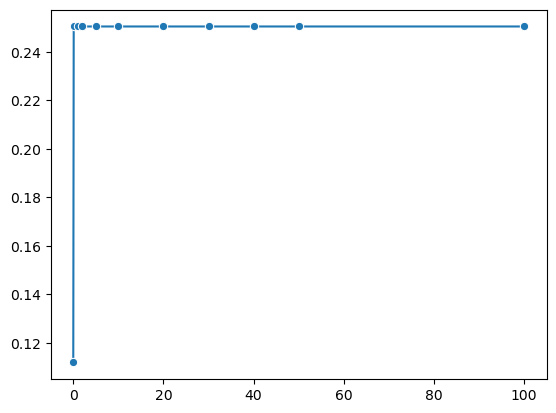

In [25]:
import seaborn as sns

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")   

In [26]:
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("r2-score = ", r2)

best alpha:  0.001
mse =  0.11187962000132382
r2-score =  0.5500124525188135


In [29]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso.fit(X_train, y_train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [30]:
# L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [35]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

models = {'Baseline': lr, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Baseline
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270


Lasso
Accuracy: 0.8703703703703703
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       145
           1       0.88      0.83      0.86       125

    accuracy                           0.87       270
   macro avg       0.87      0.87      0.87       270
weighted avg       0.87      0.87      0.87       270


Ridge
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg     